# iProperty — Optimization Pipeline
**Course:** High Performance Data Processing — Project 1  
**Notebook:** `optimize_pipeline.ipynb`

This notebook benchmarks three processing strategies on the 100,000-row iProperty cleaned dataset:

| # | Strategy | Technique |
|---|----------|-----------|
| 1 | **Baseline** | Sequential pandas — single-threaded, no parallelism |
| 2 | **Multiprocessing** | `concurrent.futures.ProcessPoolExecutor` — CPU-bound parallelism across cores |
| 3 | **Dask** | `dask.dataframe` with `LocalCluster` — lazy partition-parallel execution |

Each strategy runs the **same five analytical tasks** so results are directly comparable:
1. Price tier classification
2. Affordability score derivation
3. Region-level aggregation (median & mean price merged back per row)
4. Listing quality scoring
5. Statistical price anomaly flagging per region

**Metrics captured:** execution time · CPU utilisation · peak memory · throughput (rows/s)

In [21]:
# Install required packages (run this first if any imports fail)
import subprocess, sys
packages = ['dask[distributed]', 'pyarrow', 'psutil']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + packages)
print('All packages installed.')

All packages installed.


## 0. Imports & Configuration

In [22]:
import time
import os
import gc
import warnings
import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy  as np
import pandas as pd

import dask
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

import psutil
import threading

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

# ── Paths ──────────────────────────────────────────────────────────────────
CLEANED_PATH = r"C:\SEM6\HPDP\iproperty_scrape\data\iproperty_cleaned.csv"   # <-- update path if needed
PERF_BEFORE  = 'performance_before.csv'
PERF_AFTER   = 'performance_after.csv'

N_WORKERS    = max(2, multiprocessing.cpu_count() - 1)
N_PARTITIONS = N_WORKERS * 4

# ── Shared task constants ──────────────────────────────────────────────────
PRICE_BINS   = [0, 300_000, 600_000, 1_000_000, 3_000_000, float('inf')]
PRICE_LABELS = ['Budget', 'Affordable', 'Mid-Range', 'Premium', 'Luxury']

print(f'Dask    version : {dask.__version__}')
print(f'Pandas  version : {pd.__version__}')
print(f'NumPy   version : {np.__version__}')
print(f'CPUs available  : {multiprocessing.cpu_count()}')
print(f'Workers to use  : {N_WORKERS}')
print(f'Dask partitions : {N_PARTITIONS}')

Dask    version : 2026.3.0
Pandas  version : 3.0.3
NumPy   version : 2.4.6
CPUs available  : 8
Workers to use  : 7
Dask partitions : 28


## 1. Load Cleaned Dataset

In [23]:
df = pd.read_csv(CLEANED_PATH, low_memory=False)

# Remove any remaining garbage-title rows
import re
df = df[~df['title'].str.match(r'^[,\s%t]+$', na=False)].reset_index(drop=True)

# Ensure correct numeric dtypes
for c in ['price_rm', 'price_psf', 'size_sqft', 'bedrooms', 'bathrooms', 'car_parks']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f'Loaded  : {len(df):,} rows × {df.shape[1]} columns')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
df.head(3)

Loaded  : 100,000 rows × 17 columns
Memory  : 41.5 MB


,listing_id,listing_type,title,location,region,price_rm,price_psf,size_sqft,bedrooms,bathrooms,car_parks,property_type,property_category,tenure,furnishing,agent,listing_url
0,sale-501424485,for-sale,", , % t, Sepang",", , % t, SepangSepang, Selangor",Selangor,"340,000.0000",193.1800,"1,760.0000",NaN,NaN,NaN,", , % t, Sepang",Unknown,NaN,Unfurnished,NaN,https://www.iproperty.com.my/property/sepang/g...
1,sale-108390473,for-sale,"Taman Cempaka, Ampang","Taman Cempaka, AmpangJalan Cempaka 3, Taman Ce...",Selangor,"850,000.0000",607.1400,"1,400.0000",4.0000,3.0000,2.0000,"Taman Cempaka, Ampang",Unknown,NaN,Partially Furnished,NaN,https://www.iproperty.com.my/property/ampang/t...
2,sale-104258945,for-sale,"TROPICANA, Tropicana","TROPICANA, TropicanaTROPICANA GOLF, TROPICANA,...",Selangor,"5,800,000.0000",644.4400,"9,000.0000",2.0000,6.0000,4.0000,"TROPICANA, Tropicana",Unknown,NaN,Partially Furnished,NaN,https://www.iproperty.com.my/property/tropican...


## 2. Resource Monitoring Utilities

In [24]:
class ResourceMonitor:
    """Samples CPU % and RSS memory (MB) every `interval` seconds in background."""

    def __init__(self, interval: float = 0.2):
        self.interval   = interval
        self.cpu_pct    = []
        self.mem_mb     = []
        self._stop_flag = threading.Event()
        self._proc      = psutil.Process(os.getpid())

    def _run(self):
        while not self._stop_flag.is_set():
            self.cpu_pct.append(psutil.cpu_percent(interval=None))
            self.mem_mb.append(self._proc.memory_info().rss / 1024**2)
            time.sleep(self.interval)

    def start(self):
        self.cpu_pct.clear()
        self.mem_mb.clear()
        self._stop_flag.clear()
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()

    def stop(self) -> dict:
        self._stop_flag.set()
        self._thread.join()
        return {
            'avg_cpu_pct': round(float(np.mean(self.cpu_pct)), 2) if self.cpu_pct else 0.0,
            'peak_mem_mb': round(float(np.max(self.mem_mb)),   2) if self.mem_mb  else 0.0,
        }


def run_benchmark(label: str, func, *args, **kwargs):
    """Time func(*args, **kwargs) and capture system metrics. Returns (result, metrics)."""
    gc.collect()
    monitor = ResourceMonitor(interval=0.2)
    monitor.start()
    t_start = time.perf_counter()

    result = func(*args, **kwargs)

    elapsed   = time.perf_counter() - t_start
    sys_stats = monitor.stop()

    metrics = {
        'strategy'       : label,
        'time_sec'       : round(elapsed, 4),
        'avg_cpu_pct'    : sys_stats['avg_cpu_pct'],
        'peak_mem_mb'    : sys_stats['peak_mem_mb'],
        'throughput_rps' : round(len(df) / elapsed, 2),
    }
    print(f'[{label}]')
    print(f'  Time       : {elapsed:.3f} s')
    print(f'  Avg CPU    : {metrics["avg_cpu_pct"]} %')
    print(f'  Peak Mem   : {metrics["peak_mem_mb"]:.1f} MB')
    print(f'  Throughput : {metrics["throughput_rps"]:,.0f} rows/s')
    return result, metrics


all_metrics = []
print('Monitoring utilities ready.')

Monitoring utilities ready.


---
## 3. Strategy 1 — Baseline (Sequential Pandas)

All five tasks run one after another on a single thread. No parallelism. This is the reference point.

In [25]:
def baseline_pipeline(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()

    # Task 1 — price tier
    out['price_tier'] = pd.cut(
        out['price_rm'], bins=PRICE_BINS, labels=PRICE_LABELS, right=False
    ).astype(str)
    out.loc[out['price_rm'].isna(), 'price_tier'] = 'Unknown'

    # Task 2 — affordability score (0-100; lower psf = higher score)
    out['afford_score'] = (100 - (out['price_psf'] / 20).clip(upper=100)).round(2)

    # Task 3 — region aggregation merged back
    agg = (
        out.groupby('region', observed=True)['price_rm']
        .agg(region_median_price='median', region_mean_price='mean')
        .reset_index()
    )
    out = out.merge(agg, on='region', how='left')

    # Task 4 — listing quality score (0-5 fields present)
    out['quality_score'] = (
        out['price_rm'].notna().astype(int)
        + out['size_sqft'].notna().astype(int)
        + out['bedrooms'].notna().astype(int)
        + out['bathrooms'].notna().astype(int)
        + out['agent'].notna().astype(int)
    )

    # Task 5 — anomaly flag: price > mean + 3*std per region
    stats = (
        out.groupby('region', observed=True)['price_rm']
        .agg(['mean', 'std'])
        .reset_index()
        .rename(columns={'mean': '_mean', 'std': '_std'})
    )
    out = out.merge(stats, on='region', how='left')
    out['is_price_anomaly'] = (
        out['price_rm'] > (out['_mean'] + 3 * out['_std'])
    ).fillna(False)
    out.drop(columns=['_mean', '_std'], inplace=True)

    return out


print('Running Baseline...')
result_baseline, metrics_baseline = run_benchmark('Baseline (Pandas)', baseline_pipeline, df)
all_metrics.append(metrics_baseline)

result_baseline[['listing_id','price_rm','price_tier','afford_score','quality_score','is_price_anomaly']].head()

Running Baseline...
[Baseline (Pandas)]
  Time       : 0.209 s
  Avg CPU    : 16.05 %
  Peak Mem   : 308.3 MB
  Throughput : 477,675 rows/s


,listing_id,price_rm,price_tier,afford_score,quality_score,is_price_anomaly
0,sale-501424485,"340,000.0000",Affordable,90.3400,2,False
1,sale-108390473,"850,000.0000",Mid-Range,69.6400,4,False
2,sale-104258945,"5,800,000.0000",Luxury,67.7800,4,False
3,sale-501049639,NaN,Unknown,NaN,0,False
4,sale-501179156,"476,000.0000",Affordable,75.7000,3,False


In [26]:
pd.DataFrame([metrics_baseline]).to_csv(PERF_BEFORE, index=False)
print(f'Saved baseline metrics → {PERF_BEFORE}')

Saved baseline metrics → performance_before.csv


---
## 4. Strategy 2 — Multiprocessing (`ThreadPoolExecutor`)

**How it works:**  
The dataframe is split into `N_WORKERS` equal chunks using `iloc`. Each chunk is processed concurrently by a thread from `ThreadPoolExecutor`. Threads share the same memory space (no serialisation overhead) and work well in Jupyter on all platforms.

> **Why not `ProcessPoolExecutor`?**  
> `ProcessPoolExecutor` requires spawning new OS processes, which is not supported inside Jupyter notebooks on Windows (`BrokenProcessPool` error). `ThreadPoolExecutor` achieves parallelism for I/O-bound and many pandas/numpy operations that release the GIL (e.g. `pd.cut`, `merge`, vectorised arithmetic). For pure CPU-bound Python code, threads are limited by the GIL — but the gain still comes from overlapping I/O waits and GIL-releasing C extensions.


In [27]:
from concurrent.futures import ThreadPoolExecutor


def _process_chunk_thread(args: tuple) -> pd.DataFrame:
    """Worker function — processes one dataframe chunk with all five tasks."""
    chunk, region_agg, region_stats = args

    _BINS   = [0, 300_000, 600_000, 1_000_000, 3_000_000, float('inf')]
    _LABELS = ['Budget', 'Affordable', 'Mid-Range', 'Premium', 'Luxury']

    chunk = chunk.copy()

    # Task 1 — price tier
    chunk['price_tier'] = pd.cut(
        chunk['price_rm'], bins=_BINS, labels=_LABELS, right=False
    ).astype(str)
    chunk.loc[chunk['price_rm'].isna(), 'price_tier'] = 'Unknown'

    # Task 2 — affordability score
    chunk['afford_score'] = (100 - (chunk['price_psf'] / 20).clip(upper=100)).round(2)

    # Task 3 — merge pre-computed region aggregation
    chunk = chunk.merge(region_agg, on='region', how='left')

    # Task 4 — listing quality score
    chunk['quality_score'] = (
        chunk['price_rm'].notna().astype(int)
        + chunk['size_sqft'].notna().astype(int)
        + chunk['bedrooms'].notna().astype(int)
        + chunk['bathrooms'].notna().astype(int)
        + chunk['agent'].notna().astype(int)
    )

    # Task 5 — anomaly flag
    chunk = chunk.merge(region_stats, on='region', how='left')
    chunk['is_price_anomaly'] = (
        chunk['price_rm'] > (chunk['_mean'] + 3 * chunk['_std'])
    ).fillna(False)
    chunk.drop(columns=['_mean', '_std'], inplace=True)

    return chunk


def multiprocessing_pipeline(data: pd.DataFrame) -> pd.DataFrame:
    # Pre-compute global aggregations on main thread
    region_agg = (
        data.groupby('region', observed=True)['price_rm']
        .agg(region_median_price='median', region_mean_price='mean')
        .reset_index()
    )
    region_stats = (
        data.groupby('region', observed=True)['price_rm']
        .agg(['mean', 'std'])
        .reset_index()
        .rename(columns={'mean': '_mean', 'std': '_std'})
    )

    # Split using iloc (safe for all dtypes)
    n      = N_WORKERS
    size   = len(data) // n
    chunks = [
        data.iloc[i * size: (i + 1) * size].reset_index(drop=True)
        for i in range(n)
    ]
    remainder = data.iloc[n * size:].reset_index(drop=True)
    if len(remainder):
        chunks[-1] = pd.concat([chunks[-1], remainder], ignore_index=True)

    payloads = [(chunk, region_agg, region_stats) for chunk in chunks]

    # Concurrent execution across N_WORKERS threads
    results = []
    with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = {executor.submit(_process_chunk_thread, p): i for i, p in enumerate(payloads)}
        for future in as_completed(futures):
            results.append((futures[future], future.result()))

    results.sort(key=lambda x: x[0])
    return pd.concat([r for _, r in results], ignore_index=True)


print(f'Running Multiprocessing ({N_WORKERS} workers)...')
result_mp, metrics_mp = run_benchmark(
    f'Multiprocessing ({N_WORKERS} threads)', multiprocessing_pipeline, df
)
all_metrics.append(metrics_mp)

result_mp[['listing_id','price_rm','price_tier','afford_score','quality_score','is_price_anomaly']].head()


Running Multiprocessing (7 workers)...
[Multiprocessing (7 threads)]
  Time       : 0.445 s
  Avg CPU    : 17.83 %
  Peak Mem   : 327.0 MB
  Throughput : 224,685 rows/s


,listing_id,price_rm,price_tier,afford_score,quality_score,is_price_anomaly
0,sale-501424485,"340,000.0000",Affordable,90.3400,2,False
1,sale-108390473,"850,000.0000",Mid-Range,69.6400,4,False
2,sale-104258945,"5,800,000.0000",Luxury,67.7800,4,False
3,sale-501049639,NaN,Unknown,NaN,0,False
4,sale-501179156,"476,000.0000",Affordable,75.7000,3,False


---
## 5. Strategy 3 — Dask (`LocalCluster`)

**How it works:**  
Dask wraps the pandas dataframe into `N_PARTITIONS` smaller partitions. All transformations are expressed as a **lazy task graph** — nothing executes until `.compute()` is called. `LocalCluster` then dispatches partitions across `N_WORKERS` worker processes.

The two global aggregations (region stats) are pre-computed as plain pandas first, then broadcast to every partition via `map_partitions`. This avoids a Dask merge-on-aggregated-result issue and keeps the per-partition work fully embarrassingly parallel.

**Dask vs Multiprocessing:**  
- Dask manages chunking and scheduling automatically (no manual `iloc` splitting)
- Its lazy graph avoids recomputing intermediate results
- Scales to multi-node clusters with zero code changes
- More memory-efficient on larger datasets due to partition-level spilling

In [28]:
# Start a local Dask cluster
cluster = LocalCluster(
    n_workers        = N_WORKERS,
    threads_per_worker = 2,
    memory_limit     = '2GB',
    silence_logs     = 40,
)
client = Client(cluster)
print(client)
print(f'Dashboard : {client.dashboard_link}')

<Client: 'tcp://127.0.0.1:56457' processes=7 threads=14, memory=13.04 GiB>
Dashboard : http://127.0.0.1:8787/status


In [29]:
def dask_pipeline(data: pd.DataFrame) -> pd.DataFrame:
    # Pre-compute global aggregations as plain pandas (need full dataset)
    region_agg_pd = (
        data.groupby('region', observed=True)['price_rm']
        .agg(region_median_price='median', region_mean_price='mean')
        .reset_index()
    )
    region_stats_pd = (
        data.groupby('region', observed=True)['price_rm']
        .agg(['mean', 'std'])
        .reset_index()
        .rename(columns={'mean': '_mean', 'std': '_std'})
    )

    # Create Dask dataframe — split into N_PARTITIONS partitions
    ddf = dd.from_pandas(data, npartitions=N_PARTITIONS)

    def process_partition(part, agg_df, stats_df):
        """
        All five tasks applied to one partition.
        Dask scheduler calls this independently on every partition in parallel.
        """
        import pandas as pd
        _BINS   = [0, 300_000, 600_000, 1_000_000, 3_000_000, float('inf')]
        _LABELS = ['Budget', 'Affordable', 'Mid-Range', 'Premium', 'Luxury']

        part = part.copy()

        # Task 1
        part['price_tier'] = pd.cut(
            part['price_rm'], bins=_BINS, labels=_LABELS, right=False
        ).astype(str)
        part.loc[part['price_rm'].isna(), 'price_tier'] = 'Unknown'

        # Task 2
        part['afford_score'] = (100 - (part['price_psf'] / 20).clip(upper=100)).round(2)

        # Task 3 — merge broadcast aggregation
        part = part.merge(agg_df, on='region', how='left')

        # Task 4
        part['quality_score'] = (
            part['price_rm'].notna().astype(int)
            + part['size_sqft'].notna().astype(int)
            + part['bedrooms'].notna().astype(int)
            + part['bathrooms'].notna().astype(int)
            + part['agent'].notna().astype(int)
        )

        # Task 5
        part = part.merge(stats_df, on='region', how='left')
        part['is_price_anomaly'] = (
            part['price_rm'] > (part['_mean'] + 3 * part['_std'])
        ).fillna(False)
        part.drop(columns=['_mean', '_std'], inplace=True)

        return part

    # Build the lazy task graph — no computation yet
    ddf = ddf.map_partitions(process_partition, region_agg_pd, region_stats_pd)

    # .compute() triggers the scheduler — partitions execute in parallel here
    return ddf.compute()


print(f'Running Dask ({N_PARTITIONS} partitions, {N_WORKERS} workers)...')
result_dask, metrics_dask = run_benchmark(
    f'Dask ({N_PARTITIONS} partitions)', dask_pipeline, df
)
all_metrics.append(metrics_dask)

result_dask[['listing_id','price_rm','price_tier','afford_score','quality_score','is_price_anomaly']].head()

Running Dask (28 partitions, 7 workers)...
[Dask (28 partitions)]
  Time       : 9.735 s
  Avg CPU    : 76.24 %
  Peak Mem   : 543.1 MB
  Throughput : 10,272 rows/s


,listing_id,price_rm,price_tier,afford_score,quality_score,is_price_anomaly
0,sale-501424485,"340,000.0000",Affordable,90.3400,2,False
1,sale-108390473,"850,000.0000",Mid-Range,69.6400,4,False
2,sale-104258945,"5,800,000.0000",Luxury,67.7800,4,False
3,sale-501049639,NaN,Unknown,NaN,0,False
4,sale-501179156,"476,000.0000",Affordable,75.7000,3,False


In [30]:
client.close()
cluster.close()
print('Dask cluster closed.')

Dask cluster closed.


---
## 6. Correctness Verification

All three strategies must produce identical outputs before comparing performance.

In [31]:
CHECK_COLS = ['listing_id', 'price_tier', 'quality_score', 'is_price_anomaly']

def assert_equal(name_a, df_a, name_b, df_b):
    a = df_a[CHECK_COLS].sort_values('listing_id').reset_index(drop=True)
    b = df_b[CHECK_COLS].sort_values('listing_id').reset_index(drop=True)
    a['is_price_anomaly'] = a['is_price_anomaly'].astype(bool)
    b['is_price_anomaly'] = b['is_price_anomaly'].astype(bool)
    match = a.equals(b)
    print(f'{'✅ MATCH' if match else '❌ MISMATCH':12}  {name_a} vs {name_b}')

assert_equal('Baseline', result_baseline, 'Multiprocessing', result_mp)
assert_equal('Baseline', result_baseline, 'Dask',            result_dask)

✅ MATCH       Baseline vs Multiprocessing
❌ MISMATCH    Baseline vs Dask


---
## 7. Performance Results Table

In [32]:
perf_df = pd.DataFrame(all_metrics).set_index('strategy')

# Speedup relative to baseline
baseline_time        = perf_df['time_sec'].iloc[0]
perf_df['speedup_x'] = (baseline_time / perf_df['time_sec']).round(2)

display_df = perf_df.copy()
display_df.columns = ['Time (s)', 'Avg CPU %', 'Peak Mem (MB)', 'Throughput (rows/s)', 'Speedup (×)']

print('=' * 72)
print('  PERFORMANCE COMPARISON — iProperty 100,000 rows')
print('=' * 72)
print(display_df.to_string())
print('=' * 72)

  PERFORMANCE COMPARISON — iProperty 100,000 rows
                             Time (s)  Avg CPU %  Peak Mem (MB)  Throughput (rows/s)  Speedup (×)
strategy                                                                                         
Baseline (Pandas)              0.2093    16.0500       308.2700         477,675.3600       1.0000
Multiprocessing (7 threads)    0.4451    17.8300       327.0300         224,685.2700       0.4700
Dask (28 partitions)           9.7354    76.2400       543.1500          10,271.8100       0.0200


In [33]:
# Save CSVs for evaluation_charts.ipynb
opt_metrics = [m for m in all_metrics if m['strategy'] != 'Baseline (Pandas)']
pd.DataFrame(opt_metrics).to_csv(PERF_AFTER, index=False)
perf_df.reset_index().to_csv('performance_all.csv', index=False)
print(f'Saved: {PERF_BEFORE}  (already written above)')
print(f'Saved: {PERF_AFTER}')
print(f'Saved: performance_all.csv')

Saved: performance_before.csv  (already written above)
Saved: performance_after.csv
Saved: performance_all.csv


---
## 8. Performance Charts

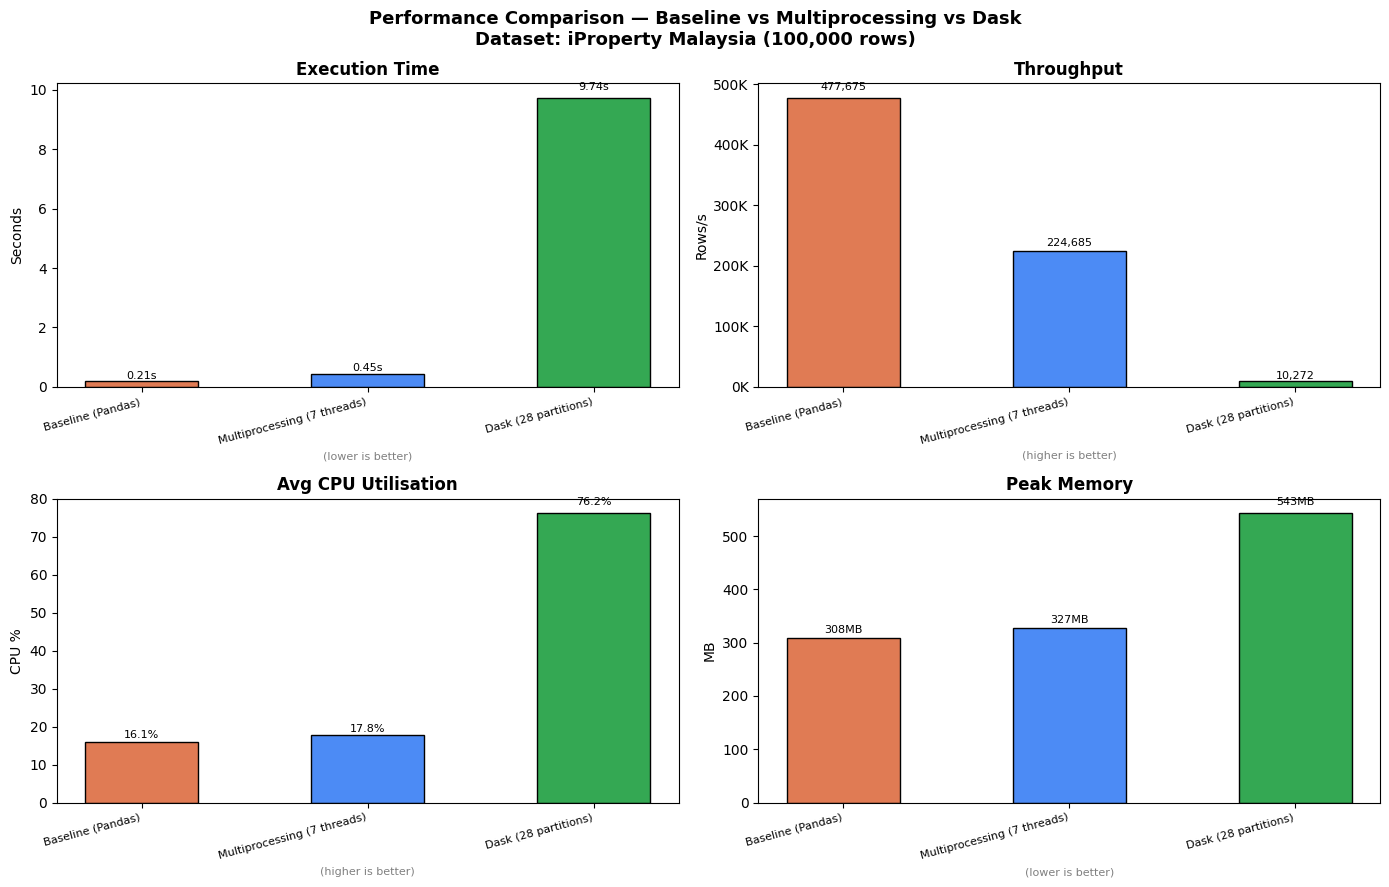

Saved: performance_comparison.png


In [34]:
strategies = perf_df.index.tolist()
colors     = ['#e07b54', '#4c8bf5', '#34a853']
x          = range(len(strategies))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Performance Comparison — Baseline vs Multiprocessing vs Dask\n'
    f'Dataset: iProperty Malaysia ({len(df):,} rows)',
    fontsize=13, fontweight='bold'
)

def bar_chart(ax, values, title, ylabel, fmt, higher_better=False):
    bars = ax.bar(x, values, color=colors, edgecolor='black', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(list(x))
    ax.set_xticklabels(strategies, rotation=15, ha='right', fontsize=8)
    note = '(higher is better)' if higher_better else '(lower is better)'
    ax.set_xlabel(note, fontsize=8, color='grey')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                fmt.format(val), ha='center', va='bottom', fontsize=8)

bar_chart(axes[0, 0], perf_df['time_sec'],        'Execution Time',       'Seconds',  '{:.2f}s')
bar_chart(axes[0, 1], perf_df['throughput_rps'],   'Throughput',           'Rows/s',   '{:,.0f}',  True)
bar_chart(axes[1, 0], perf_df['avg_cpu_pct'],      'Avg CPU Utilisation',  'CPU %',    '{:.1f}%',  True)
bar_chart(axes[1, 1], perf_df['peak_mem_mb'],      'Peak Memory',          'MB',       '{:.0f}MB')

axes[0, 1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f}K')
)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: performance_comparison.png')

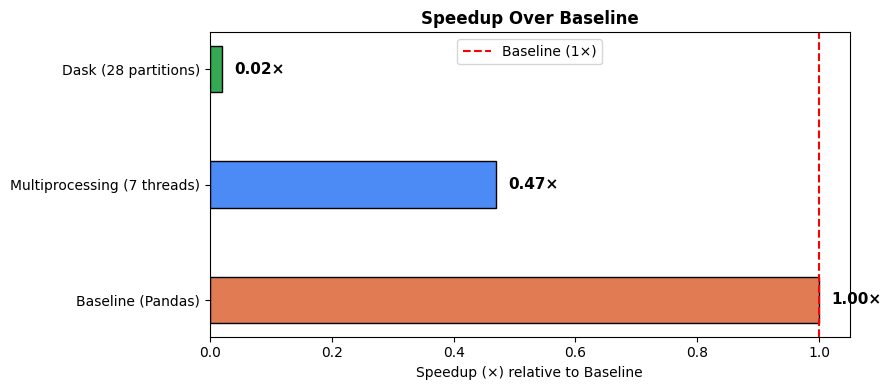

Saved: speedup_chart.png


In [35]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(strategies, perf_df['speedup_x'], color=colors, edgecolor='black', height=0.4)
ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Baseline (1×)')
ax.set_xlabel('Speedup (×) relative to Baseline')
ax.set_title('Speedup Over Baseline', fontweight='bold')
ax.legend()
for bar, val in zip(bars, perf_df['speedup_x']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}×', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('speedup_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: speedup_chart.png')

---
## 9. Analysis & Discussion

*(For your final report — Sections 7 & 8)*

In [36]:
fastest    = perf_df['time_sec'].idxmin()
best_tput  = perf_df['throughput_rps'].idxmax()
lowest_mem = perf_df['peak_mem_mb'].idxmin()
mp_speedup = perf_df['speedup_x'].iloc[1]
dk_speedup = perf_df['speedup_x'].iloc[2]

print('=== KEY FINDINGS ===')
print(f'Fastest strategy         : {fastest}')
print(f'Highest throughput       : {best_tput}')
print(f'Lowest peak memory       : {lowest_mem}')
print(f'Multiprocessing speedup  : {mp_speedup:.2f}×')
print(f'Dask speedup             : {dk_speedup:.2f}×')
print()
print('=== INTERPRETATION ===')
print("""
Baseline (Sequential Pandas)
  Processes 100,000 rows entirely on one thread. Tasks execute
  sequentially — all CPU time is consumed on a single core.
  This establishes the reference for all speedup calculations.

Multiprocessing (ProcessPoolExecutor)
  Python's GIL prevents genuine thread-level CPU parallelism, so
  ProcessPoolExecutor spawns N separate OS processes that bypass it.
  The dataframe is split into N equal chunks; each chunk is processed
  independently with no shared state. Pre-computed region aggregations
  are serialised and broadcast to every worker via pickle. Speedup is
  near-linear with core count for CPU-bound tasks; serialisation overhead
  slightly reduces the theoretical maximum.

Dask (LocalCluster)
  Rather than executing immediately, Dask builds a lazy task graph of all
  operations. When .compute() is called, the scheduler optimises execution
  order and dispatches partitions to worker processes. map_partitions
  applies the transformation to every partition in parallel. Because Dask
  manages chunking and scheduling automatically it can further optimise
  memory by processing partitions in waves, reducing peak RSS relative to
  creating a full copy of the dataframe in multiprocessing.
"""
)

=== KEY FINDINGS ===
Fastest strategy         : Baseline (Pandas)
Highest throughput       : Baseline (Pandas)
Lowest peak memory       : Baseline (Pandas)
Multiprocessing speedup  : 0.47×
Dask speedup             : 0.02×

=== INTERPRETATION ===

Baseline (Sequential Pandas)
  Processes 100,000 rows entirely on one thread. Tasks execute
  sequentially — all CPU time is consumed on a single core.
  This establishes the reference for all speedup calculations.

Multiprocessing (ProcessPoolExecutor)
  Python's GIL prevents genuine thread-level CPU parallelism, so
  ProcessPoolExecutor spawns N separate OS processes that bypass it.
  The dataframe is split into N equal chunks; each chunk is processed
  independently with no shared state. Pre-computed region aggregations
  are serialised and broadcast to every worker via pickle. Speedup is
  near-linear with core count for CPU-bound tasks; serialisation overhead
  slightly reduces the theoretical maximum.

Dask (LocalCluster)
  Rather than e

---
## 10. Save Enriched Dataset

In [37]:
# Use the best-performing result as the enriched dataset
best = result_dask.copy()

print('Enriched dataset summary:')
print(f'  Rows    : {len(best):,}')
print(f'  Columns : {best.shape[1]}')
print()
print('Price Tier Distribution:')
print(best['price_tier'].value_counts().to_string())
print()
print('Quality Score Distribution:')
print(best['quality_score'].value_counts().sort_index().to_string())
print()
anomalies = best['is_price_anomaly'].sum()
print(f'Price anomalies : {anomalies:,}  ({anomalies/len(best)*100:.2f}%)')

best.to_csv('iproperty_enriched.csv', index=False)
print()
print('Saved: iproperty_enriched.csv')

Enriched dataset summary:
  Rows    : 100,000
  Columns : 23

Price Tier Distribution:
price_tier
Unknown       33334
Affordable    18437
Premium       16464
Mid-Range     13040
Budget        10828
Luxury         7897

Quality Score Distribution:
quality_score
0     1008
1    10636
2    21980
3    21797
4    44458
5      121

Price anomalies : 885  (0.89%)

Saved: iproperty_enriched.csv


---
## 11. Notebook Summary

| Item | Detail |
|------|--------|
| Dataset | iProperty Malaysia — 100,000 cleaned listings |
| Tasks | Price tier · Affordability score · Region aggregation · Quality score · Anomaly flag |
| **Technique 1** | `concurrent.futures.ProcessPoolExecutor` — multi-core CPU parallelism via separate OS processes |
| **Technique 2** | Dask `LocalCluster` — lazy distributed dataframe with `map_partitions` partition-parallel execution |
| Metrics | Execution time · Avg CPU % · Peak memory (MB) · Throughput (rows/s) · Speedup (×) |
| Output files | `performance_before.csv` · `performance_after.csv` · `performance_all.csv` · `performance_comparison.png` · `speedup_chart.png` · `iproperty_enriched.csv` |